<a href="https://colab.research.google.com/github/Rakesh-2211/M-PSK-and-M-QAM/blob/main/Experiment_11_%E2%80%94_M_PSK_and_M_QAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Mandatory Validation: QPSK ---
Average Energy BEFORE normalization: 1.0000
Average Energy AFTER normalization:  1.0000

--- Mandatory Validation: 8-PSK ---
Average Energy BEFORE normalization: 1.0000
Average Energy AFTER normalization:  1.0000

--- Mandatory Validation: 16-QAM ---
Average Energy BEFORE normalization: 10.0000
Average Energy AFTER normalization:  1.0000

--- Mandatory Validation: 64-QAM ---
Average Energy BEFORE normalization: 42.0000
Average Energy AFTER normalization:  1.0000



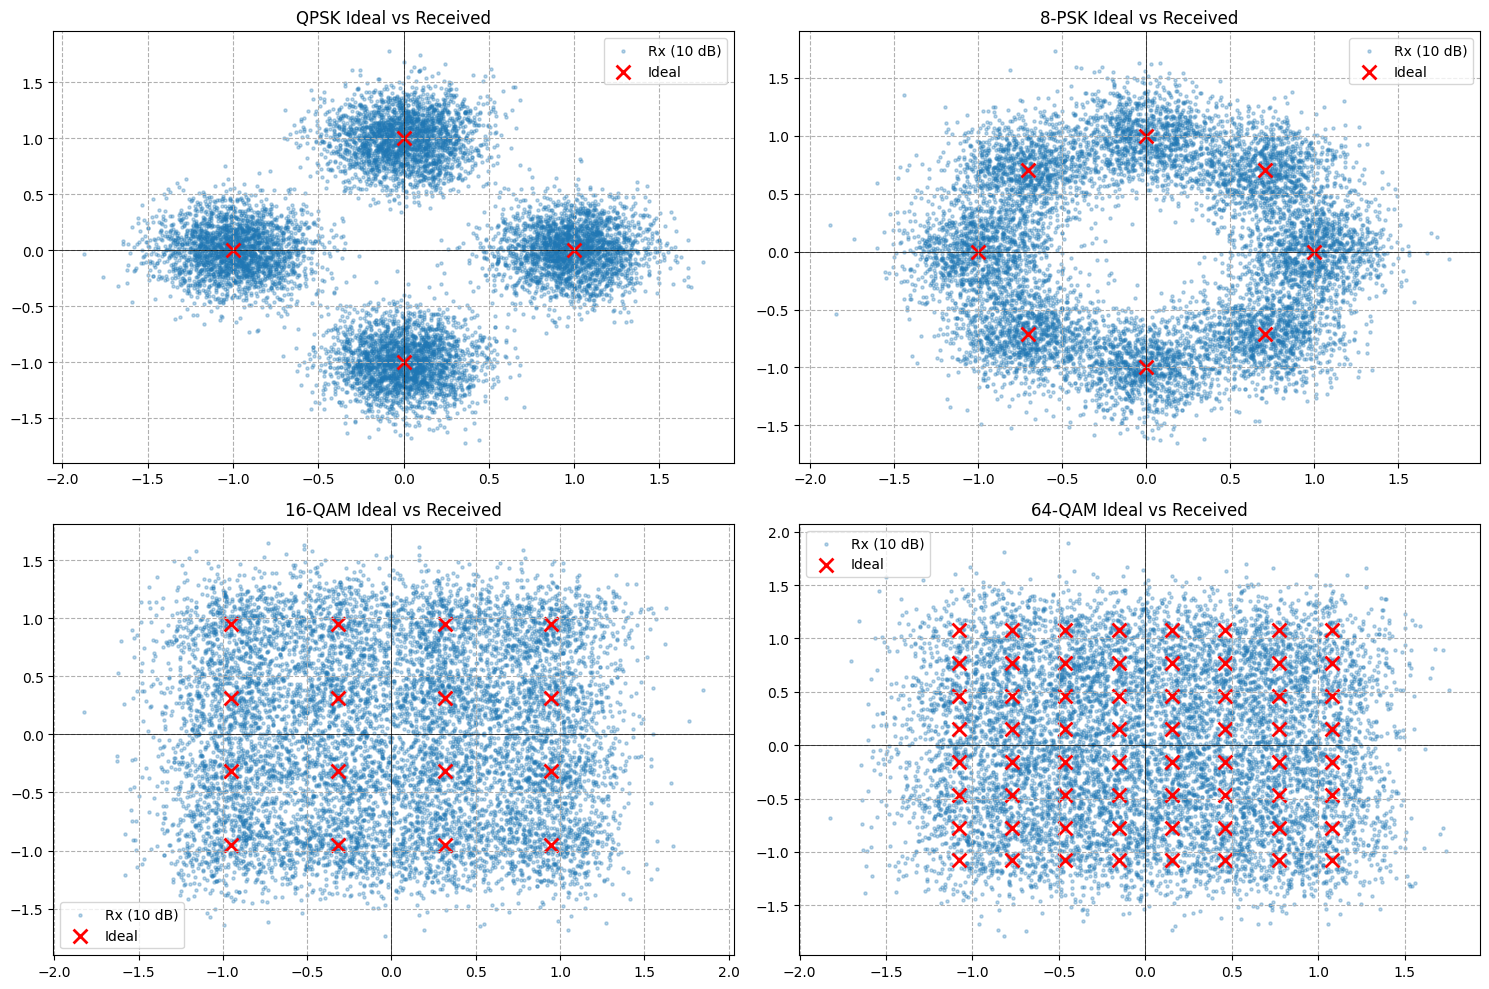

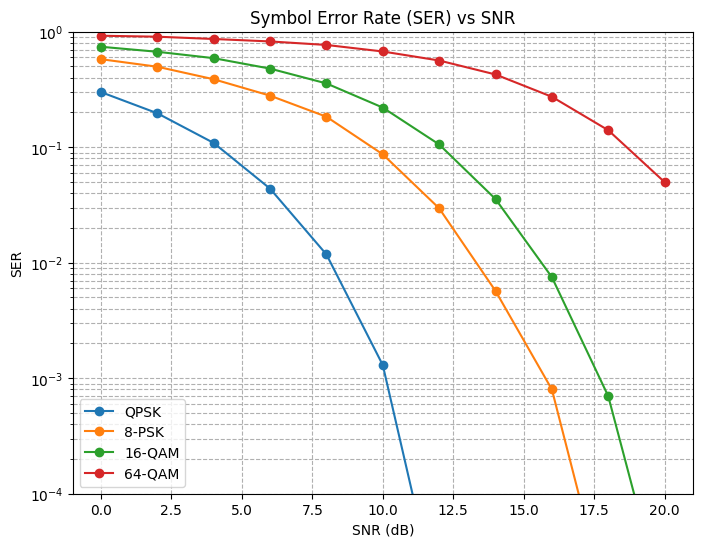

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ==========================================
# 1. Constellation Generation & Normalization
# ==========================================

def gray_code(n):
    """Generates an n-bit Gray code sequence."""
    return [i ^ (i >> 1) for i in range(1 << n)]

def generate_mpsk(M):
    """Generates an M-PSK constellation (Gray mapped)."""
    m = int(np.log2(M))
    gray_seq = gray_code(m)
    # Map gray sequence to phases
    phases = np.zeros(M)
    for i, idx in enumerate(gray_seq):
        phases[idx] = 2 * np.pi * i / M
    constellation = np.cos(phases) + 1j * np.sin(phases)
    return constellation

def generate_mqam(M):
    """Generates a square M-QAM constellation (Gray mapped)."""
    m = int(np.log2(M))
    m_per_axis = int(np.log2(np.sqrt(M)))

    # 1D PAM Gray mapping
    gray_seq = gray_code(m_per_axis)
    pam_levels = np.arange(-np.sqrt(M)+1, np.sqrt(M), 2)
    pam = np.zeros(int(np.sqrt(M)))
    for i, idx in enumerate(gray_seq):
        pam[idx] = pam_levels[i]

    # 2D Grid
    X, Y = np.meshgrid(pam, pam)
    constellation = X.flatten() + 1j * Y.flatten()
    return constellation

def normalize_and_validate(constellation, name):
    """Normalizes constellation to unit average energy and prints validation."""
    print(f"--- Mandatory Validation: {name} ---")
    E_avg_before = np.mean(np.abs(constellation)**2)
    print(f"Average Energy BEFORE normalization: {E_avg_before:.4f}")

    normalized_const = constellation / np.sqrt(E_avg_before)

    E_avg_after = np.mean(np.abs(normalized_const)**2)
    print(f"Average Energy AFTER normalization:  {E_avg_after:.4f}\n")

    return normalized_const

# Generate and Normalize Constellations
constellations = {
    'QPSK': normalize_and_validate(generate_mpsk(4), 'QPSK'),
    '8-PSK': normalize_and_validate(generate_mpsk(8), '8-PSK'),
    '16-QAM': normalize_and_validate(generate_mqam(16), '16-QAM'),
    '64-QAM': normalize_and_validate(generate_mqam(64), '64-QAM')
}

# ==========================================
# 2. Channel & Minimum Distance Detection
# ==========================================

def awgn_channel(symbols, snr_db):
    """Adds AWGN to the signal based on the target SNR in dB."""
    snr_linear = 10**(snr_db / 10.0)
    # Since average symbol energy is normalized to 1, noise variance is 1/SNR
    noise_var = 1 / snr_linear
    noise = np.sqrt(noise_var / 2) * (np.random.randn(len(symbols)) + 1j * np.random.randn(len(symbols)))
    return symbols + noise

def minimum_distance_detector(rx_symbols, ideal_constellation):
    """Demaps received symbols to nearest ideal constellation point."""
    # Reshape for cdist: real and imag components as 2D coordinates
    rx_coords = np.column_stack((rx_symbols.real, rx_symbols.imag))
    ideal_coords = np.column_stack((ideal_constellation.real, ideal_constellation.imag))

    # Calculate Euclidean distance between all rx symbols and ideal points
    distances = cdist(rx_coords, ideal_coords)

    # Find the index of the minimum distance
    detected_indices = np.argmin(distances, axis=1)
    return detected_indices

# ==========================================
# 3. Simulation & Visualizations
# ==========================================

N_SYMBOLS = 10000
snr_test_points = [0, 5, 10, 20] # Test at 0, 5, 10, 20 dB

plt.figure(figsize=(15, 10))

for i, (name, const) in enumerate(constellations.items()):
    # Generate random symbols
    tx_indices = np.random.randint(0, len(const), N_SYMBOLS)
    tx_symbols = const[tx_indices]

    # Test at 10 dB for the constellation plot visualization
    rx_symbols_10db = awgn_channel(tx_symbols, 10)
    rx_symbols_20db = awgn_channel(tx_symbols, 20)

    # Plot Ideal vs Received (10 dB & 20 dB overlapping or side-by-side)
    plt.subplot(2, 2, i+1)
    plt.scatter(rx_symbols_10db.real, rx_symbols_10db.imag, alpha=0.3, label='Rx (10 dB)', s=5)
    plt.scatter(const.real, const.imag, c='red', marker='x', s=100, label='Ideal', linewidths=2)
    plt.title(f"{name} Ideal vs Received")
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(True, linestyle='--')
    plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 4. SER Calculation (Simulation vs SNR)
# ==========================================

snr_range = np.arange(0, 21, 2)
ser_results = {name: [] for name in constellations.keys()}

for name, const in constellations.items():
    M = len(const)
    for snr in snr_range:
        tx_indices = np.random.randint(0, M, N_SYMBOLS)
        tx_symbols = const[tx_indices]

        rx_symbols = awgn_channel(tx_symbols, snr)
        rx_indices = minimum_distance_detector(rx_symbols, const)

        ser = np.mean(tx_indices != rx_indices)
        ser_results[name].append(ser)

# Plot SER
plt.figure(figsize=(8, 6))
for name, ser in ser_results.items():
    # Filter out absolute zero for log scale plotting
    ser = [s if s > 0 else 1e-5 for s in ser]
    plt.semilogy(snr_range, ser, marker='o', label=name)

plt.title('Symbol Error Rate (SER) vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('SER')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.ylim([1e-4, 1])
plt.show()